# Example: thermal spice fitting
This examples uses UC Merced shading IVs to develop the cell temperature simulation

In [1]:
import os
from pathlib import Path

project_root = Path.cwd().parents[1]
os.chdir(project_root)   # now cwd is .../pvcracks

from pvcracks.pvspice.spice_tools import run_ngspice
from pvcracks.pvspice.spice_tools import ngpsice_read_voltage_current_modules
from pvcracks.pvspice.spice_tools import module_to_netlist

# spicepath = "/home/nrjost/.conda/envs/pyhpc_spice/bin/ngspice" #kahunaimport numpy as np
spicepath = "C://Program Files//ngspice-47_64//Spice64//bin//ngspice.exe"
import pandas as pd
import pvlib

In [2]:
project_root

WindowsPath('c:/Users/Norman/pvcracks')

In [3]:
ivdata = pd.read_csv("docs/data/IVshaded/Data.csv")
ivdata.dtypes

Date_Time                        object
Irradiance_61                   float64
Voltage                          object
Current                          object
Amb_Temp                        float64
wind_speed                      float64
Observed_Temp of Shaded Cell    float64
Bias_V                            int64
Reverse_Bias_I (Shaded Cell)    float64
Reverse_Bias_V (Shaded Cell)    float64
Shade_Percentage                float64
Middle_Temp                     float64
dtype: object

In [4]:
import ast
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Make a copy so the original dataframe is unchanged
iv = ivdata.copy()

# Parse Date_Time
iv["Date_Time"] = pd.to_datetime(iv["Date_Time"], errors="coerce")

# Function to convert string-list cells into numpy arrays
def parse_array_cell(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return np.array(x, dtype=float)

    if pd.isna(x):
        return np.array([])

    s = str(x).strip()

    try:
        return np.array(ast.literal_eval(s), dtype=float)
    except Exception:
        # fallback in case literal_eval fails
        s = s.strip("[]")
        return np.fromstring(s, sep=",")

# Convert Voltage and Current columns
iv["Voltage_array"] = iv["Voltage"].apply(parse_array_cell)
iv["Current_array"] = iv["Current"].apply(parse_array_cell)

# Keep only rows where voltage and current arrays are valid and same length
valid = iv.apply(
    lambda row: len(row["Voltage_array"]) == len(row["Current_array"]) and len(row["Voltage_array"]) > 1,
    axis=1
)

iv_valid = iv.loc[valid].copy()

print(f"Valid IV curves: {len(iv_valid)}")
print(f"Invalid IV curves skipped: {len(iv) - len(iv_valid)}")

Valid IV curves: 39
Invalid IV curves skipped: 0


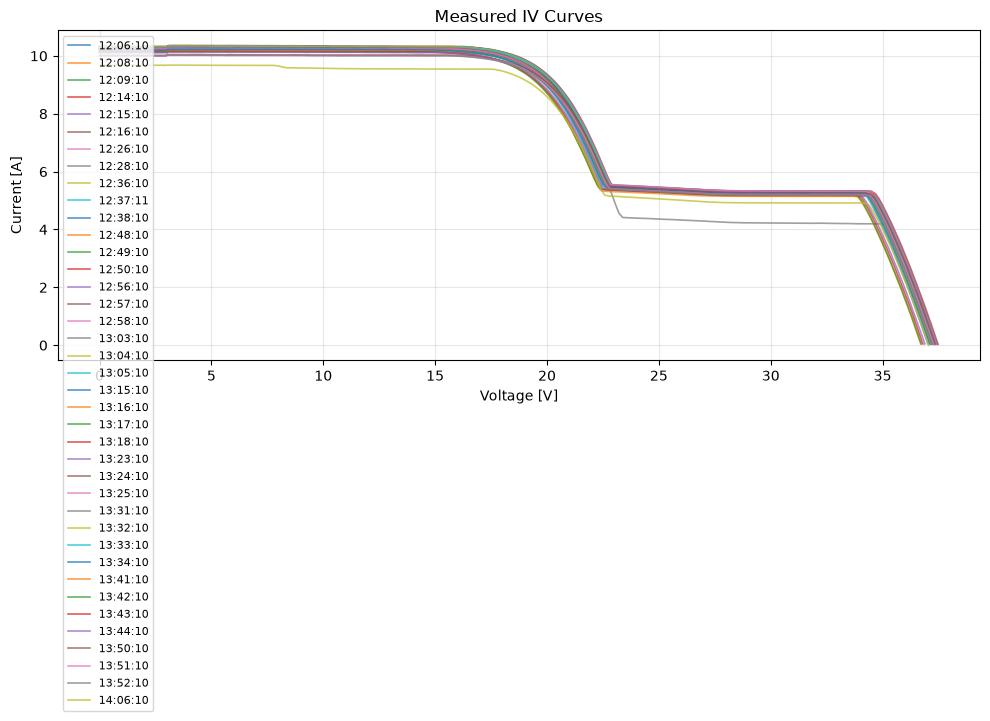

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in iv_valid.iterrows():
    V = row["Voltage_array"]
    I = row["Current_array"]

    ax.plot(
        V,
        I,
        linewidth=1.2,
        alpha=0.75,
        label=row["Date_Time"].strftime("%H:%M:%S") if pd.notna(row["Date_Time"]) else None
    )

ax.set_xlabel("Voltage [V]")
ax.set_ylabel("Current [A]")
ax.set_title("Measured IV Curves")
ax.grid(True, alpha=0.3)

# If you have many curves, the legend may be crowded
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

In [6]:
# Load the CEC module database from pvlib/SAM
cec_modules = pvlib.pvsystem.retrieve_sam("CECMod")

# Your module name
query = "LG320N1K-A5"

# CEC/SAM names often replace "-" with "_" and include manufacturer names
query_norm = query.replace("-", "_").upper()

matches = [
    name for name in cec_modules.columns
    if query_norm in name.upper().replace("-", "_")
]

print("Matches found:")
for m in matches:
    print(m)

# Select the first match
module_name = matches[0]
module_data = cec_modules[module_name]

print("\nSelected module:")
print(module_name)

print("\nModule data:")
print(module_data)

Matches found:
LG_Electronics_Inc__LG320N1K_A5

Selected module:
LG_Electronics_Inc__LG320N1K_A5

Module data:
Technology            Mono-c-Si
Bifacial                      0
STC                     320.346
PTC                       294.7
A_c                       1.649
Length                    1.662
Width                     0.992
N_s                          60
I_sc_ref                  10.19
V_oc_ref                   40.8
I_mp_ref                   9.62
V_mp_ref                   33.3
alpha_sc               0.002038
beta_oc                -0.10608
T_NOCT                     47.7
a_ref                  1.476693
I_L_ref               10.200071
I_o_ref                     0.0
R_s                    0.307043
R_sh_ref              310.65448
Adjust                 4.687218
gamma_r                  -0.357
BIPV                          N
Version       SAM 2018.11.11 r2
Date                   1/3/2019
Name: LG_Electronics_Inc__LG320N1K_A5, dtype: object


In [7]:
# IV fitting:
row_iloc = 0   # choose which IV curve to simulate
row = ivdata.iloc[row_iloc]

N_s = 60
N_modules = 1
N_byp = 2

n_rows = 6
n_cols = 10

# Bottom-left physical cell:
# row 5, col 0, if row 0 is top and col 0 is left
shaded_cell_index = 5 * n_cols + 0

print("Shaded cell index:", shaded_cell_index)

md = module_data.copy()

N_s_cec = int(float(md["N_s"]))
I_sc_ref = float(md["I_sc_ref"])
V_oc_ref = float(md["V_oc_ref"])
I_mp_ref = float(md["I_mp_ref"])
V_mp_ref = float(md["V_mp_ref"])
alpha_sc = float(md["alpha_sc"])
beta_oc = float(md["beta_oc"])
a_ref = float(md["a_ref"])
I_L_ref = float(md["I_L_ref"])
I_o_ref = float(md["I_o_ref"])
R_s_ref = float(md["R_s"])
R_sh_ref = float(md["R_sh_ref"])
Adjust = float(md["Adjust"])

if I_o_ref <= 0 or not np.isfinite(I_o_ref):
    I_o_ref = (I_L_ref - V_oc_ref / R_sh_ref) / np.expm1(V_oc_ref / a_ref)
    print(f"Estimated I_o_ref = {I_o_ref:.4e} A")
else:
    print(f"Using CEC I_o_ref = {I_o_ref:.4e} A")

Shaded cell index: 50
Using CEC I_o_ref = 1.0086e-11 A


In [8]:
G_unshaded = float(row["Irradiance_61"])

shade_pct = float(row["Shade_Percentage"])
shade_frac = np.clip(shade_pct / 100.0, 0.0, 1.0)

# If Shade_Percentage = 49, shaded cell gets 51% irradiance
G_shaded = G_unshaded * (1.0 - shade_frac)

# Use Middle_Temp for most cells
T_unshaded = float(row["Middle_Temp"])

# Use observed shaded cell temperature for the shaded cell
T_shaded = float(row["Observed_Temp of Shaded Cell"])

print("Date_Time:", row["Date_Time"])
print("Unshaded irradiance:", G_unshaded)
print("Shaded irradiance:", G_shaded)
print("Shade percentage:", shade_pct)
print("Unshaded cell temp:", T_unshaded)
print("Shaded cell temp:", T_shaded)

Date_Time: 2025-09-14T12:06:10
Unshaded irradiance: 989.21
Shaded irradiance: 504.49710000000005
Shade percentage: 49.0
Unshaded cell temp: 44.11791
Shaded cell temp: 82.4


In [9]:
IL_unshaded, I0_unshaded, Rs_module_unshaded, Rsh_module_unshaded, nNsVth_unshaded = pvlib.pvsystem.calcparams_cec(
    effective_irradiance=G_unshaded,
    temp_cell=T_unshaded,
    alpha_sc=alpha_sc,
    a_ref=a_ref,
    I_L_ref=I_L_ref,
    I_o_ref=I_o_ref,
    R_sh_ref=R_sh_ref,
    R_s=R_s_ref,
    Adjust=Adjust,
)

In [10]:
IL_shaded, I0_shaded, Rs_module_shaded, Rsh_module_shaded, nNsVth_shaded = pvlib.pvsystem.calcparams_cec(
    effective_irradiance=max(G_shaded, 1e-6),
    temp_cell=T_shaded,
    alpha_sc=alpha_sc,
    a_ref=a_ref,
    I_L_ref=I_L_ref,
    I_o_ref=I_o_ref,
    R_sh_ref=R_sh_ref,
    R_s=R_s_ref,
    Adjust=Adjust,
)

In [11]:
sd_unshaded = pvlib.pvsystem.singlediode(
    photocurrent=IL_unshaded,
    saturation_current=I0_unshaded,
    resistance_series=Rs_module_unshaded,
    resistance_shunt=Rsh_module_unshaded,
    nNsVth=nNsVth_unshaded,
)

v_oc_sim = float(sd_unshaded["v_oc"])

print("Estimated unshaded module Voc:", v_oc_sim)

Estimated unshaded module Voc: 38.6518778387981


In [12]:
Rs_cell_unshaded = Rs_module_unshaded / N_s
Rsh_cell_unshaded = Rsh_module_unshaded / N_s

Rs_cell_shaded = Rs_module_shaded / N_s
Rsh_cell_shaded = Rsh_module_shaded / N_s

# Thermal voltage at unshaded cell temperature
k_B = 1.380649e-23
q_e = 1.602176634e-19
T_K = T_unshaded + 273.15
Vth_cell = k_B * T_K / q_e

# SPICE diode ideality factor N
ideality_factor = nNsVth_unshaded / (N_s * Vth_cell)

# Use unshaded saturation current for the common SPICE diode model
saturation_current = I0_unshaded

print("IL unshaded:", IL_unshaded)
print("IL shaded:", IL_shaded)
print("Rs cell unshaded:", Rs_cell_unshaded)
print("Rsh cell unshaded:", Rsh_cell_unshaded)
print("Rsh cell shaded:", Rsh_cell_shaded)
print("SPICE ideality factor:", ideality_factor)
print("SPICE saturation current:", saturation_current)

IL unshaded: 10.126747588516295
IL shaded: 5.202156675180904
Rs cell unshaded: 0.005117383333333334
Rsh cell unshaded: 5.234050066888392
Rsh cell shaded: 10.26284326840861
SPICE ideality factor: 0.9579244607561156
SPICE saturation current: 2.0780120598826555e-10


In [13]:
cell_currents = np.full(N_s, IL_unshaded, dtype=float)
series_resistances = np.full(N_s, Rs_cell_unshaded, dtype=float)
shunt_resistances = np.full(N_s, Rsh_cell_unshaded, dtype=float)

# Apply shade to bottom-left cell
cell_currents[shaded_cell_index] = IL_shaded
series_resistances[shaded_cell_index] = Rs_cell_shaded
shunt_resistances[shaded_cell_index] = Rsh_cell_shaded

print("Cell photocurrent array:")
print(cell_currents)

Cell photocurrent array:
[10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759  5.20215668 10.12674759 10.12674759 10.12674759
 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759 10.12674759]


In [14]:
spice_path = "docs/data/IVshaded"

breakdown_voltage = 12.0

# In module_to_netlist, v_bypass is used as BV in:
# .model sdby D (IS=1e-7 N=1 BV={v_bypass} IBV=20)
# So this is the reverse breakdown voltage of the bypass diode model.
v_bypass = 20

circuit_content, halfcut = module_to_netlist(
    path=spice_path,
    N_s=N_s,
    cell_currents=cell_currents,
    series_resistances=series_resistances,
    shunt_resistances=shunt_resistances,
    ideality_factor=ideality_factor,
    saturation_current=saturation_current,
    breakdown_voltage=breakdown_voltage,
    v_bypass=v_bypass,
    v_oc=v_oc_sim,
    TNOM=T_unshaded,
    circuit_name="solar_circuit",
)

print("halfcut:", halfcut)

All series interconnection of 60 solar cells
halfcut: False


In [15]:

circuit_file = (
    project_root
    / "docs"
    / "data"
    / "IVshaded"
    / "solar_circuit.cir"
) #slight modification because windows

print(circuit_file)

run_ngspice(
    ngpsice_path=spicepath,
    circuit_file=circuit_file,
)

c:\Users\Norman\pvcracks\docs\data\IVshaded\solar_circuit.cir


In [16]:
voltage_spice, current_spice, df_spice = ngpsice_read_voltage_current_modules(spice_path)

# Depending on ngspice sign convention, source current may be negative.
# Flip so current is positive like your measured IV curves.
if len(df_spice) > 0 and np.nanmedian(df_spice["I"]) < 0:
    df_spice["I"] = -df_spice["I"]

df_spice.head()

,V,I
0,0.0,10.114580
1,0.1,10.114103
2,0.2,10.113625
3,0.3,10.113148
4,0.4,10.112671


In [17]:
if isinstance(row["Voltage"], str):
    V_meas = np.asarray(ast.literal_eval(row["Voltage"]), dtype=float)
else:
    V_meas = np.asarray(row["Voltage"], dtype=float)

if isinstance(row["Current"], str):
    I_meas = np.asarray(ast.literal_eval(row["Current"]), dtype=float)
else:
    I_meas = np.asarray(row["Current"], dtype=float)

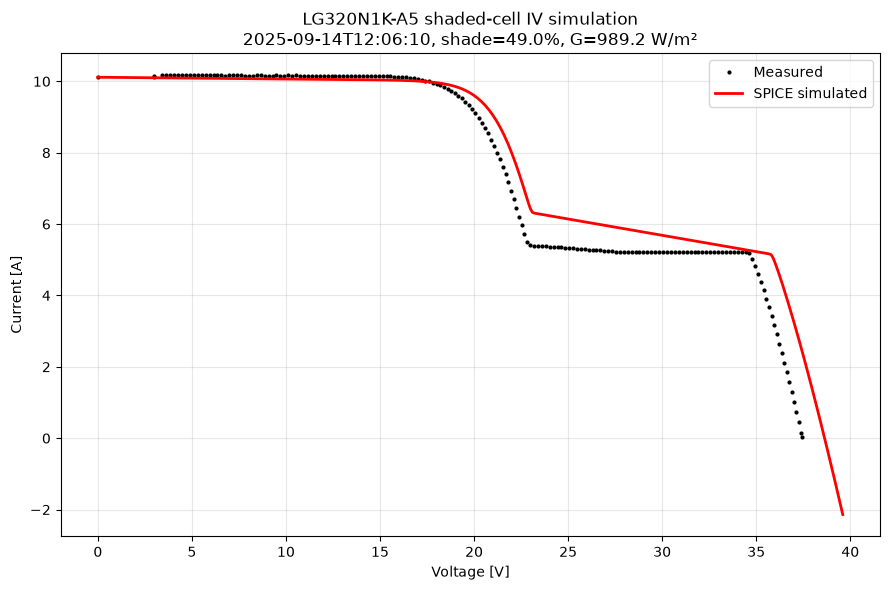

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    V_meas,
    I_meas,
    "k.",
    markersize=4,
    label="Measured",
)

ax.plot(
    df_spice["V"],
    df_spice["I"],
    "r-",
    linewidth=2,
    label="SPICE simulated",
)

ax.set_xlabel("Voltage [V]")
ax.set_ylabel("Current [A]")
ax.set_title(
    f"LG320N1K-A5 shaded-cell IV simulation\n"
    f"{row['Date_Time']}, shade={shade_pct:.1f}%, "
    f"G={G_unshaded:.1f} W/m²"
)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [19]:
#Read cell level IVs
def ngspice_read_cell_level_ivs(
    path,
    N_s=60,
    series_resistances=None,
    output_filename="solar_circuit.out",
    current_col="i(v1)",
    flip_module_current_if_negative=True,
):
    """
    Read ngspice ASCII raw output and reconstruct cell-level IV data.

    Parameters
    ----------
    path : str
        Folder containing the ngspice output file.
    N_s : int
        Number of cells in the module.
    series_resistances : float, list, or array, optional
        Per-cell series resistance values used in the SPICE netlist.
        If provided, cell current is calculated from voltage across each Rs.
        If None, only cell voltages are returned.
    output_filename : str
        Name of ngspice output file. Default is 'solar_circuit.out'.
    current_col : str
        Name of module current column in ngspice output. Usually 'i(v1)'.
    flip_module_current_if_negative : bool
        If True, flips module current sign when median current is negative.

    Returns
    -------
    df_cells_long : pandas.DataFrame
        Long-format cell-level IV dataframe with columns:
        sweep_V, module_V, module_I, cell, V_cell, V_diode, V_rs,
        and I_cell if series_resistances is provided.

    df_cells_wide : pandas.DataFrame
        Wide-format dataframe with one row per sweep point and columns:
        sweep_V, module_V, module_I, V_cell_0 ... V_cell_N,
        and optionally I_cell_0 ... I_cell_N.

    df_raw : pandas.DataFrame
        Raw ngspice variables as columns.

    Notes
    -----
    This assumes the standard non-halfcut pvspice node pattern:

        cell n:
            Rs_n from node 2n+1 to node 2n+2
            diode/Rp/current source from node 2n+2 to node 2n+3

        last cell ends at ground node 0.

    Therefore:
        V_cell_n = V(2n+1) - V(2n+3)
        V_diode_n = V(2n+2) - V(2n+3)
        V_rs_n = V(2n+1) - V(2n+2)

    For the last cell, V(2n+3) is replaced with ground, 0 V.
    """

    import os
    import numpy as np
    import pandas as pd

    output_file = os.path.join(path, output_filename)

    with open(output_file, "r") as f:
        lines = f.readlines()

    # ---------------------------------------------------------
    # Parse header information
    # ---------------------------------------------------------
    nvars = None
    npoints = None
    variables_start = None
    values_start = None

    for i, line in enumerate(lines):
        s = line.strip()

        if s.startswith("No. Variables:"):
            nvars = int(s.split(":")[1].strip())

        if s.startswith("No. Points:"):
            npoints = int(s.split(":")[1].strip())

        if s.startswith("Variables:"):
            variables_start = i + 1

        if s.startswith("Values:"):
            values_start = i + 1
            break

    if nvars is None:
        raise ValueError("Could not find 'No. Variables:' in ngspice output.")

    if variables_start is None:
        raise ValueError("Could not find 'Variables:' section in ngspice output.")

    if values_start is None:
        raise ValueError("Could not find 'Values:' section in ngspice output.")

    # ---------------------------------------------------------
    # Parse variable names
    # ---------------------------------------------------------
    var_names = []

    for line in lines[variables_start:values_start - 1]:
        parts = line.split()

        if len(parts) >= 2:
            var_names.append(parts[1])

    if len(var_names) != nvars:
        raise ValueError(
            f"Expected {nvars} variables, but parsed {len(var_names)} variable names."
        )

    # ---------------------------------------------------------
    # Parse values
    # ---------------------------------------------------------
    data = []
    current_point = []

    for line in lines[values_start:]:
        s = line.strip()

        if s == "":
            continue

        parts = s.split()

        # First line of each point looks like:
        #     0    0.000000e+00
        # Continuation lines look like:
        #          5.176018e-02
        if len(parts) >= 2:
            try:
                int(parts[0])
                value = float(parts[1])
            except ValueError:
                value = float(parts[0])
        else:
            value = float(parts[0])

        current_point.append(value)

        if len(current_point) == nvars:
            data.append(current_point)
            current_point = []

    df_raw = pd.DataFrame(data, columns=var_names)

    if npoints is not None and len(df_raw) != npoints:
        print(
            f"Warning: header says {npoints} points, "
            f"but parsed {len(df_raw)} points."
        )

    # ---------------------------------------------------------
    # Identify sweep/module voltage and current
    # ---------------------------------------------------------
    if "v(v-sweep)" in df_raw.columns:
        sweep_V = df_raw["v(v-sweep)"].to_numpy(dtype=float)
    else:
        sweep_V = df_raw.iloc[:, 0].to_numpy(dtype=float)

    if "v(1)" in df_raw.columns:
        module_V = df_raw["v(1)"].to_numpy(dtype=float)
    else:
        module_V = sweep_V.copy()

    if current_col in df_raw.columns:
        module_I = df_raw[current_col].to_numpy(dtype=float)
    else:
        matching_current_cols = [c for c in df_raw.columns if c.lower().startswith("i(")]
        if len(matching_current_cols) == 0:
            raise ValueError("Could not find any current column like i(v1).")
        current_col = matching_current_cols[-1]
        print(f"Using current column: {current_col}")
        module_I = df_raw[current_col].to_numpy(dtype=float)

    if flip_module_current_if_negative and np.nanmedian(module_I) < 0:
        module_I = -module_I

    # ---------------------------------------------------------
    # Expand series resistance array if provided
    # ---------------------------------------------------------
    calculate_cell_current = series_resistances is not None

    if calculate_cell_current:
        if np.isscalar(series_resistances):
            Rs_cells = np.full(N_s, float(series_resistances))
        else:
            Rs_cells = np.asarray(series_resistances, dtype=float)

            if len(Rs_cells) == 1:
                Rs_cells = np.full(N_s, float(Rs_cells[0]))
            elif len(Rs_cells) != N_s:
                raise ValueError(
                    f"series_resistances must have length 1 or N_s={N_s}, "
                    f"but got length {len(Rs_cells)}."
                )

    # ---------------------------------------------------------
    # Reconstruct cell voltages and currents
    # ---------------------------------------------------------
    df_cells_wide = pd.DataFrame()
    df_cells_wide["sweep_V"] = sweep_V
    df_cells_wide["module_V"] = module_V
    df_cells_wide["module_I"] = module_I

    long_rows = []

    n_points = len(df_raw)

    for n in range(N_s):
        start_node = 2 * n + 1
        after_rs_node = 2 * n + 2

        if n == N_s - 1:
            end_node = 0
        else:
            end_node = 2 * n + 3

        start_col = f"v({start_node})"
        after_rs_col = f"v({after_rs_node})"

        if start_col not in df_raw.columns:
            raise ValueError(f"Missing node voltage column {start_col}")

        if after_rs_col not in df_raw.columns:
            raise ValueError(f"Missing node voltage column {after_rs_col}")

        V_start = df_raw[start_col].to_numpy(dtype=float)
        V_after_rs = df_raw[after_rs_col].to_numpy(dtype=float)

        if end_node == 0:
            V_end = np.zeros(n_points)
        else:
            end_col = f"v({end_node})"

            if end_col not in df_raw.columns:
                raise ValueError(f"Missing node voltage column {end_col}")

            V_end = df_raw[end_col].to_numpy(dtype=float)

        # Full cell terminal voltage, including Rs
        V_cell = V_start - V_end

        # Diode/Rp/current-source junction voltage, excluding Rs
        V_diode = V_after_rs - V_end

        # Series resistor voltage, using netlist orientation
        V_rs = V_start - V_after_rs

        df_cells_wide[f"V_cell_{n}"] = V_cell
        df_cells_wide[f"V_diode_{n}"] = V_diode
        df_cells_wide[f"V_rs_{n}"] = V_rs

        if calculate_cell_current:
            # Positive PV current convention for your netlist
            I_cell = (V_after_rs - V_start) / Rs_cells[n]
            df_cells_wide[f"I_cell_{n}"] = I_cell
        else:
            I_cell = np.full(n_points, np.nan)

        for k in range(n_points):
            long_rows.append(
                {
                    "sweep_V": sweep_V[k],
                    "module_V": module_V[k],
                    "module_I": module_I[k],
                    "cell": n,
                    "V_cell": V_cell[k],
                    "V_diode": V_diode[k],
                    "V_rs": V_rs[k],
                    "I_cell": I_cell[k],
                }
            )

    df_cells_long = pd.DataFrame(long_rows)

    return df_cells_long, df_cells_wide, df_raw

In [20]:
df_cells_long, df_cells_wide, df_raw = ngspice_read_cell_level_ivs(
    path=spice_path,
    N_s=60,
    series_resistances=series_resistances,
    output_filename="solar_circuit.out",
)

C:\Users\Norman\AppData\Local\Temp\ipykernel_37256\2706883637.py:260: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cells_wide[f"V_diode_{n}"] = V_diode
C:\Users\Norman\AppData\Local\Temp\ipykernel_37256\2706883637.py:261: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cells_wide[f"V_rs_{n}"] = V_rs
C:\Users\Norman\AppData\Local\Temp\ipykernel_37256\2706883637.py:266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider jo

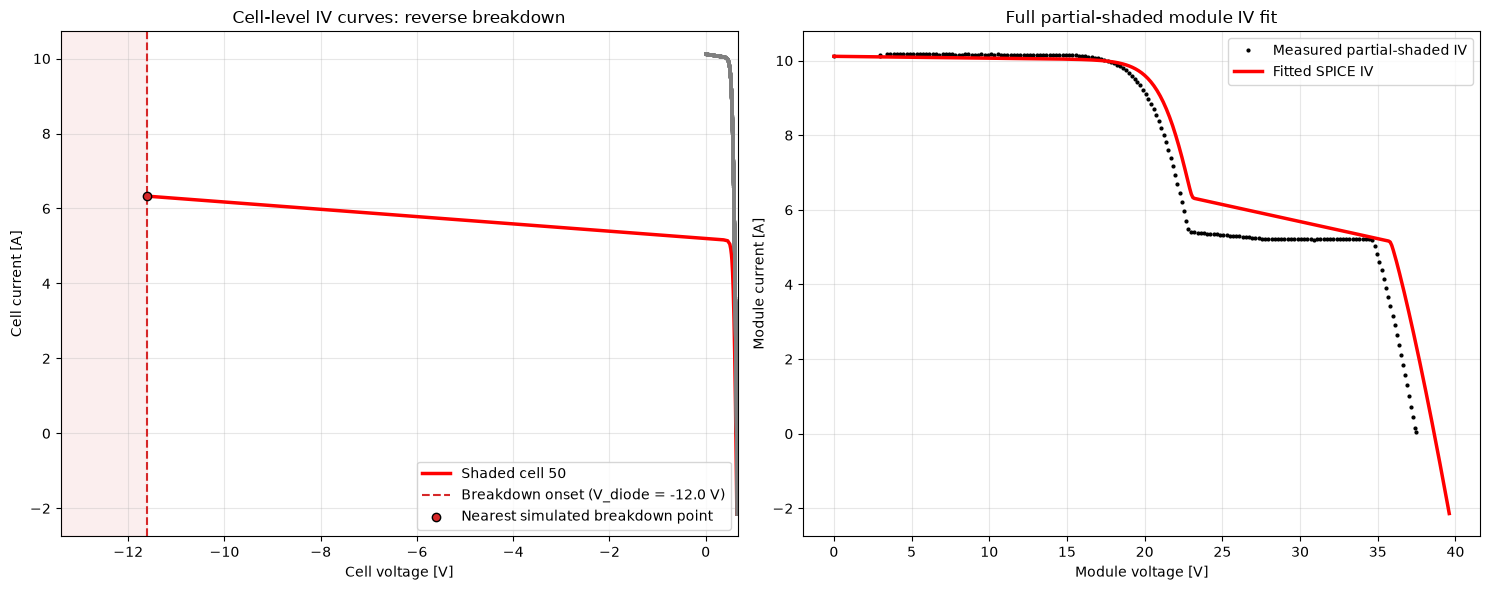

In [21]:
fig, (ax_cells, ax_module) = plt.subplots(1, 2, figsize=(15, 6))

shaded_curve = df_cells_long[df_cells_long["cell"] == shaded_cell_index]
# The SPICE BV parameter applies to the diode junction, not the cell
# terminal voltage that also includes the series-resistance drop.
breakdown_point = shaded_curve.loc[
    (shaded_curve["V_diode"] + breakdown_voltage).abs().idxmin()
]
breakdown_cell_voltage = float(breakdown_point["V_cell"])

# Keep the reverse-bias region visible even when the sweep point nearest
# breakdown lies between DC voltage steps.
reverse_plot_min = min(
    float(shaded_curve["V_cell"].min()),
    breakdown_cell_voltage - 0.15 * breakdown_voltage,
)
cell_voltage_max = float(df_cells_long["V_cell"].max())

for cell in range(N_s):
    d = df_cells_long[df_cells_long["cell"] == cell]

    if cell == shaded_cell_index:
        ax_cells.plot(
            d["V_cell"],
            d["I_cell"],
            "r-",
            linewidth=2.5,
            label=f"Shaded cell {cell}",
        )
    else:
        ax_cells.plot(
            d["V_cell"],
            d["I_cell"],
            color="gray",
            alpha=0.75,
            linewidth=2.5,
        )

ax_cells.axvspan(reverse_plot_min, breakdown_cell_voltage, color="tab:red", alpha=0.08)
ax_cells.axvline(
    breakdown_cell_voltage,
    color="tab:red",
    linestyle="--",
    linewidth=1.5,
    label=f"Breakdown onset (V_diode = {-breakdown_voltage:.1f} V)",
)
ax_cells.scatter(
    breakdown_point["V_cell"],
    breakdown_point["I_cell"],
    color="tab:red",
    edgecolor="black",
    zorder=3,
    label="Nearest simulated breakdown point",
)
ax_cells.set_xlim(reverse_plot_min, cell_voltage_max)
ax_cells.set_xlabel("Cell voltage [V]")
ax_cells.set_ylabel("Cell current [A]")
ax_cells.set_title("Cell-level IV curves: reverse breakdown")
ax_cells.grid(True, alpha=0.3)
ax_cells.legend()

ax_module.plot(
    V_meas,
    I_meas,
    "k.",
    markersize=4,
    label="Measured partial-shaded IV",
)
ax_module.plot(
    df_spice["V"],
    df_spice["I"],
    "r-",
    linewidth=2.5,
    label="Fitted SPICE IV",
)
ax_module.set_xlabel("Module voltage [V]")
ax_module.set_ylabel("Module current [A]")
ax_module.set_title("Full partial-shaded module IV fit")
ax_module.grid(True, alpha=0.3)
ax_module.legend()

fig.tight_layout()
plt.show()

In [22]:
df_cells_wide["P_module"] = df_cells_wide["module_V"] * df_cells_wide["module_I"]

mpp_idx = df_cells_wide["P_module"].idxmax()

V_mpp_module = df_cells_wide.loc[mpp_idx, "module_V"]
I_mpp_module = df_cells_wide.loc[mpp_idx, "module_I"]
P_mpp_module = df_cells_wide.loc[mpp_idx, "P_module"]

print("Module MPP index:", mpp_idx)
print("Module Vmp [V]:", V_mpp_module)
print("Module Imp [A]:", I_mpp_module)
print("Module Pmp [W]:", P_mpp_module)

Module MPP index: 203
Module Vmp [V]: 20.30000000000002
Module Imp [A]: 9.478893777808851
Module Pmp [W]: 192.42154368951986


C:\Users\Norman\AppData\Local\Temp\ipykernel_37256\2485987322.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cells_wide["P_module"] = df_cells_wide["module_V"] * df_cells_wide["module_I"]


In [23]:
cell = shaded_cell_index

V_cell_mpp = df_cells_wide.loc[mpp_idx, f"V_cell_{cell}"]
I_cell_mpp = df_cells_wide.loc[mpp_idx, f"I_cell_{cell}"]

P_cell_elec_mpp = V_cell_mpp * I_cell_mpp

print("Shaded cell index:", cell)
print("Shaded cell voltage at module MPP [V]:", V_cell_mpp)
print("Shaded cell current at module MPP [A]:", I_cell_mpp)
print("Shaded cell electrical power at module MPP [W]:", P_cell_elec_mpp)

Shaded cell index: 50
Shaded cell voltage at module MPP [V]: -11.598719911659627
Shaded cell current at module MPP [A]: 6.3291670793433825
Shaded cell electrical power at module MPP [W]: -73.4102362274007


In [24]:
A_module = float(module_data["A_c"])
A_cell = A_module / N_s

print("Module area [m^2]:", A_module)
print("Cell area [m^2]:", A_cell)

Module area [m^2]: 1.649
Cell area [m^2]: 0.027483333333333335


In [25]:
# Faiman temperature model + reverse-bias hotspot heating
# Taken from https://pvpmc.sandia.gov/modeling-guide/2-dc-module-iv/module-temperature/faiman-module-temperature-model/

absorptance = 0.98

G_cell = G_shaded  # W/m^2

T_amb = float(row["Amb_Temp"])
wind_speed = float(row["wind_speed"])

# Faiman coefficients upper range of parameters on the pvpmc website
U0 = 26.5#25.0       # W/m^2/K 
U1 = 7.68#6.84       # W/m^3 s K

# Effective Faiman heat-loss coefficient
U = U0 + U1 * wind_speed

# Reverse-bias electrical heating
# P_cell_elec_mpp < 0 means the cell is dissipating electrical power
P_reverse_heat = max(0.0, -P_cell_elec_mpp)  # W

# Convert localized electrical heating to heat flux
q_reverse = P_reverse_heat / A_cell  # W/m^2

# Standard Faiman temperature from incident irradiance
T_cell_faiman = T_amb + G_cell / U

# Add the temperature rise caused by reverse-bias heating
delta_T_reverse = q_reverse / U

T_cell_est = T_cell_faiman + delta_T_reverse

print("Shaded cell irradiance [W/m^2]:", G_cell)
print("Reverse-bias electrical heat [W]:", P_reverse_heat)
print("Reverse-bias heat flux [W/m^2]:", q_reverse)

print("Ambient temperature [C]:", T_amb)
print("Wind speed [m/s]:", wind_speed)
print("Faiman heat-loss coefficient [W/m^2/K]:", U)

print("Faiman cell temperature without reverse bias [C]:", T_cell_faiman)
print("Temperature rise from reverse bias [C]:", delta_T_reverse)
print("Estimated shaded cell temperature [C]:", T_cell_est)

Shaded cell irradiance [W/m^2]: 504.49710000000005
Reverse-bias electrical heat [W]: 73.4102362274007
Reverse-bias heat flux [W/m^2]: 2671.081973101299
Ambient temperature [C]: 27.16882
Wind speed [m/s]: 3.404462
Faiman heat-loss coefficient [W/m^2/K]: 52.64626816
Faiman cell temperature without reverse bias [C]: 36.751590396312935
Temperature rise from reverse bias [C]: 50.73639721211531
Estimated shaded cell temperature [C]: 87.48798760842824


In [26]:
T_cell_measured = float(row["Observed_Temp of Shaded Cell"])

print("Measured shaded cell temperature [C]:", T_cell_measured)
print("Model error [C]:", T_cell_est - T_cell_measured)

Measured shaded cell temperature [C]: 82.4
Model error [C]: 5.087987608428236


SHADED CELL RESULTS AT MODULE MPP
Shaded cell index:                    50
Shaded irradiance:                    504.497 W/m²
Shaded cell voltage:                  -11.5987 V
Shaded cell current:                  6.3292 A
Shaded cell electrical power:         -73.4102 W
Reverse-bias electrical heating:      73.4102 W
Reverse-bias heat flux:               2671.082 W/m²

Ambient temperature:                  27.17 °C
Wind speed:                           3.404 m/s
Faiman U0:                            26.500 W/m²/K
Faiman U1:                            7.680
Effective heat-loss coefficient U:    52.646 W/m²/K

Faiman temp without reverse heating:  36.75 °C
Reverse-bias temperature rise:        50.74 °C
Estimated shaded-cell temperature:    87.49 °C

Measured shaded-cell temperature:     82.40 °C
Temperature error:                    5.09 °C

HOTTEST CELLS


,cell,G_cell_Wm2,V_cell_MPP_V,I_cell_MPP_A,P_elec_cell_W,P_reverse_heat_W,q_reverse_W_m2,q_total_W_m2,DeltaT_solar_C,DeltaT_reverse_C,T_faiman_no_reverse_C,T_cell_C,is_shaded
50,50,504.4971,-11.598720,6.329167,-73.410236,73.410236,2671.081973,3175.579073,9.582770,50.736397,36.751590,87.487988,True
0,0,989.2100,0.519301,9.478894,4.922399,0.000000,0.000000,989.210000,18.789746,0.000000,45.958566,45.958566,False
2,2,989.2100,0.519301,9.478894,4.922399,0.000000,0.000000,989.210000,18.789746,0.000000,45.958566,45.958566,False
1,1,989.2100,0.519301,9.478894,4.922399,0.000000,0.000000,989.210000,18.789746,0.000000,45.958566,45.958566,False
4,4,989.2100,0.519301,9.478894,4.922399,0.000000,0.000000,989.210000,18.789746,0.000000,45.958566,45.958566,False
5,5,989.2100,0.519301,9.478894,4.922399,0.000000,0.000000,989.210000,18.789746,0.000000,45.958566,45.958566,False
6,6,989.2100,0.519301,9.478894,4.922399,0.000000,0.000000,989.210000,18.789746,0.000000,45.958566,45.958566,False
7,7,989.2100,0.519301,9.478894,4.922399,0.000000,0.000000,989.210000,18.789746,0.000000,45.958566,45.958566,False
8,8,989.2100,0.519301,9.478894,4.922399,0.000000,0.000000,989.210000,18.789746,0.000000,45.958566,45.958566,False
9,9,989.2100,0.519301,9.478894,4.922399,0.000000,0.000000,989.210000,18.789746,0.000000,45.958566,45.958566,False


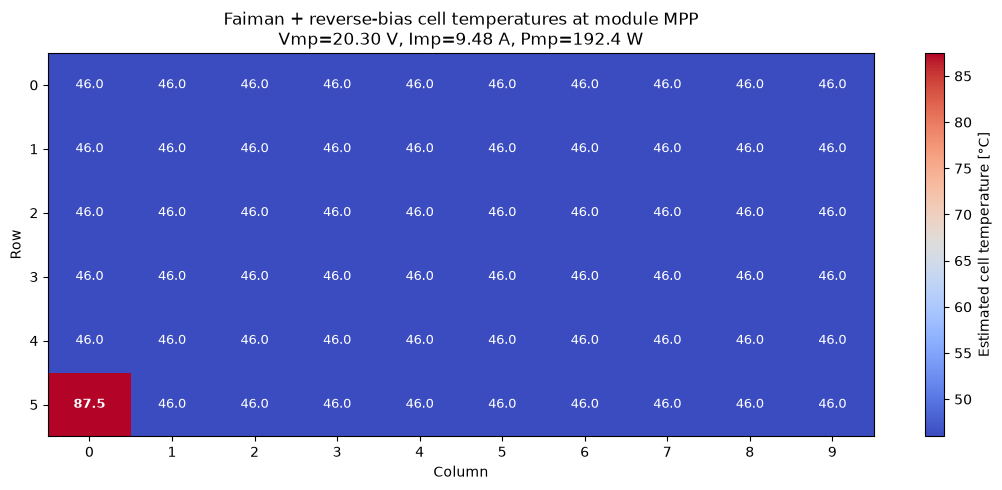

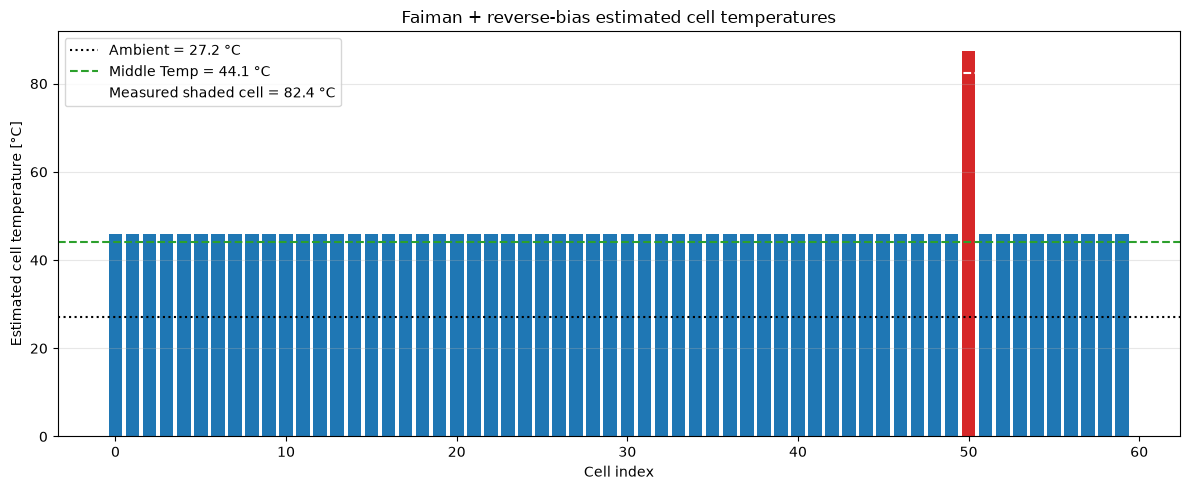

In [27]:
# ============================================================
# ALL-CELL TEMPERATURE MAP
# Faiman model + reverse-bias hotspot heating
#
# Based on:
# T_cell = T_amb + G_cell / U + q_reverse / U
#
# where:
# U = U0 + U1 * wind_speed
# q_reverse = max(0, -P_elec_cell) / A_cell
#
# This uses the SAME thermal formulation as the single-cell
# Faiman calculation above.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Environmental conditions
# ------------------------------------------------------------

T_amb = float(row["Amb_Temp"])
T_middle = float(row["Middle_Temp"])
wind_speed = float(row["wind_speed"])

# Faiman coefficients
# Upper end of the ranges used previously
U0 = 26.5       # W/m²/K
U1 = 7.68       # W/m²/K per m/s

# If you want to use fitted coefficients instead, replace with:
#
# U0 = U0_fit
# U1 = U1_fit

U = U0 + U1 * wind_speed

# ------------------------------------------------------------
# 2. Extract all cell operating points at module MPP
# ------------------------------------------------------------

V_cells_mpp = np.array(
    [
        df_cells_wide.loc[mpp_idx, f"V_cell_{c}"]
        for c in range(N_s)
    ],
    dtype=float
)

I_cells_mpp = np.array(
    [
        df_cells_wide.loc[mpp_idx, f"I_cell_{c}"]
        for c in range(N_s)
    ],
    dtype=float
)

# Correct sign convention if required
if np.nanmedian(I_cells_mpp) < 0:
    I_cells_mpp = -I_cells_mpp


# Electrical power of every cell at module MPP
#
# Positive:
#     cell is producing electrical power
#
# Negative:
#     cell is consuming electrical power
#     -> reverse-bias dissipation
#
P_cells_elec_mpp = (
    V_cells_mpp
    * I_cells_mpp
)

# ------------------------------------------------------------
# 3. Assign irradiance to each cell
# ------------------------------------------------------------

G_cells = np.full(
    N_s,
    G_unshaded,
    dtype=float
)

G_cells[shaded_cell_index] = G_shaded

# ------------------------------------------------------------
# 4. Reverse-bias electrical heating
# ------------------------------------------------------------

# Only negative electrical power contributes additional
# reverse-bias heating.
#
# Positive electrical power gives zero additional heating
# in this Faiman-based formulation.

P_reverse_heat_cells = np.maximum(
    0.0,
    -P_cells_elec_mpp
)

# Convert reverse-bias electrical power to heat flux
# [W/m²]

q_reverse_cells = (
    P_reverse_heat_cells
    / A_cell
)

# ------------------------------------------------------------
# 5. Standard Faiman irradiance temperature contribution
# ------------------------------------------------------------

delta_T_solar_cells = (
    G_cells
    / U
)

# ------------------------------------------------------------
# 6. Reverse-bias temperature contribution
# ------------------------------------------------------------

delta_T_reverse_cells = (
    q_reverse_cells
    / U
)

# ------------------------------------------------------------
# 7. Final cell temperatures
#
# T_cell =
#     T_ambient
#     + irradiance contribution
#     + reverse-bias contribution
# ------------------------------------------------------------

T_cells_faiman = (
    T_amb
    + delta_T_solar_cells
)

T_cells = (
    T_cells_faiman
    + delta_T_reverse_cells
)


# For clarity, total effective heat flux entering thermal model
q_total_cells = (
    G_cells
    + q_reverse_cells
)

# ------------------------------------------------------------
# 8. Shaded-cell results
# ------------------------------------------------------------

V_shaded_mpp = (
    V_cells_mpp[shaded_cell_index]
)

I_shaded_mpp = (
    I_cells_mpp[shaded_cell_index]
)

P_elec_shaded_mpp = (
    P_cells_elec_mpp[shaded_cell_index]
)

P_reverse_shaded = (
    P_reverse_heat_cells[shaded_cell_index]
)

q_reverse_shaded = (
    q_reverse_cells[shaded_cell_index]
)

T_shaded_faiman = (
    T_cells_faiman[shaded_cell_index]
)

delta_T_reverse_shaded = (
    delta_T_reverse_cells[shaded_cell_index]
)

T_shaded_est = (
    T_cells[shaded_cell_index]
)

print("=" * 65)
print("SHADED CELL RESULTS AT MODULE MPP")
print("=" * 65)

print(
    f"Shaded cell index:                    "
    f"{shaded_cell_index}"
)

print(
    f"Shaded irradiance:                    "
    f"{G_shaded:.3f} W/m²"
)

print(
    f"Shaded cell voltage:                  "
    f"{V_shaded_mpp:.4f} V"
)

print(
    f"Shaded cell current:                  "
    f"{I_shaded_mpp:.4f} A"
)

print(
    f"Shaded cell electrical power:         "
    f"{P_elec_shaded_mpp:.4f} W"
)

print(
    f"Reverse-bias electrical heating:      "
    f"{P_reverse_shaded:.4f} W"
)

print(
    f"Reverse-bias heat flux:               "
    f"{q_reverse_shaded:.3f} W/m²"
)

print()

print(
    f"Ambient temperature:                  "
    f"{T_amb:.2f} °C"
)

print(
    f"Wind speed:                           "
    f"{wind_speed:.3f} m/s"
)

print(
    f"Faiman U0:                            "
    f"{U0:.3f} W/m²/K"
)

print(
    f"Faiman U1:                            "
    f"{U1:.3f}"
)

print(
    f"Effective heat-loss coefficient U:    "
    f"{U:.3f} W/m²/K"
)

print()

print(
    f"Faiman temp without reverse heating:  "
    f"{T_shaded_faiman:.2f} °C"
)

print(
    f"Reverse-bias temperature rise:        "
    f"{delta_T_reverse_shaded:.2f} °C"
)

print(
    f"Estimated shaded-cell temperature:    "
    f"{T_shaded_est:.2f} °C"
)

# ------------------------------------------------------------
# 9. Compare with measured shaded-cell temperature
# ------------------------------------------------------------

T_measured_shaded = np.nan

if "Observed_Temp of Shaded Cell" in row.index:

    T_measured_shaded = float(
        row["Observed_Temp of Shaded Cell"]
    )

    print()

    print(
        f"Measured shaded-cell temperature:     "
        f"{T_measured_shaded:.2f} °C"
    )

    print(
        f"Temperature error:                    "
        f"{T_shaded_est - T_measured_shaded:.2f} °C"
    )

# ------------------------------------------------------------
# 10. Create summary dataframe
# ------------------------------------------------------------

df_cell_temps = pd.DataFrame(
    {
        "cell": np.arange(N_s),
        "G_cell_Wm2":
            G_cells,
        "V_cell_MPP_V":
            V_cells_mpp,
        "I_cell_MPP_A":
            I_cells_mpp,
        "P_elec_cell_W":
            P_cells_elec_mpp,
        "P_reverse_heat_W":
            P_reverse_heat_cells,
        "q_reverse_W_m2":
            q_reverse_cells,
        "q_total_W_m2":
            q_total_cells,
        "DeltaT_solar_C":
            delta_T_solar_cells,
        "DeltaT_reverse_C":
            delta_T_reverse_cells,
        "T_faiman_no_reverse_C":
            T_cells_faiman,
        "T_cell_C":
            T_cells,
    }
)

df_cell_temps["is_shaded"] = (
    df_cell_temps["cell"]
    == shaded_cell_index
)

print()
print("=" * 65)
print("HOTTEST CELLS")
print("=" * 65)

display(
    df_cell_temps
    .sort_values(
        "T_cell_C",
        ascending=False
    )
    .head(10)
)

# ------------------------------------------------------------
# 11. 6 x 10 cell temperature heatmap
# ------------------------------------------------------------

n_rows = 6
n_cols = 10

if n_rows * n_cols != N_s:

    raise ValueError(
        f"Heatmap dimensions {n_rows} x {n_cols} "
        f"do not match N_s={N_s}"
    )

T_cells_2d = T_cells.reshape(
    n_rows,
    n_cols
)

fig, ax = plt.subplots(
    figsize=(11, 5)
)

im = ax.imshow(
    T_cells_2d,
    cmap="coolwarm",
    aspect="auto",
    origin="upper"
)

cbar = plt.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "Estimated cell temperature [°C]"
)

ax.set_title(
    f"Faiman + reverse-bias cell temperatures at module MPP\n"
    f"Vmp={V_mpp_module:.2f} V, "
    f"Imp={I_mpp_module:.2f} A, "
    f"Pmp={P_mpp_module:.1f} W"
)

ax.set_xlabel("Column")
ax.set_ylabel("Row")

ax.set_xticks(
    np.arange(n_cols)
)

ax.set_yticks(
    np.arange(n_rows)
)

# Add temperature labels
for r in range(n_rows):

    for c in range(n_cols):

        cell_idx = (
            r * n_cols + c
        )

        if cell_idx == shaded_cell_index:

            text_color = "white"
            fontweight = "bold"

        else:

            text_color = "white"
            fontweight = "normal"


        ax.text(
            c,
            r,
            f"{T_cells_2d[r, c]:.1f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9,
            fontweight=fontweight,
        )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. Bar plot of all cell temperatures
# ------------------------------------------------------------

cell_numbers = np.arange(N_s)

colors = np.array(
    ["tab:blue"] * N_s,
    dtype=object
)

colors[shaded_cell_index] = "tab:red"

fig, ax = plt.subplots(
    figsize=(12, 5)
)

ax.bar(
    cell_numbers,
    T_cells,
    color=colors
)

# Ambient temperature reference
ax.axhline(
    T_amb,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label=(
        f"Ambient = "
        f"{T_amb:.1f} °C"
    )
)

# Middle temperature measurement reference
ax.axhline(
    T_middle,
    color="tab:green",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Middle Temp = "
        f"{T_middle:.1f} °C"
    )
)

# Measured shaded-cell temperature
if np.isfinite(T_measured_shaded):

    ax.axhline(
        T_measured_shaded,
        color="white",
        linestyle="--",
        linewidth=1.5,
        label=(
            f"Measured shaded cell = "
            f"{T_measured_shaded:.1f} °C"
        )
    )

ax.set_xlabel("Cell index")

ax.set_ylabel(
    "Estimated cell temperature [°C]"
)

ax.set_title(
    "Faiman + reverse-bias estimated cell temperatures"
)

ax.grid(
    True,
    axis="y",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

